In [74]:
import os
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt

In [75]:
def smooth(values, weight=0.99):
    # """Applies exponential moving average smoothing."""
    smoothed = []
    last = values[0]
    for val in values:
        smoothed_val = last * weight + (1 - weight) * val
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

In [76]:
log_dir = "../data/training-logs/method-comparison/calgan_l1"

# Load events
event_acc = EventAccumulator(log_dir)
event_acc.Reload()

# Check available scalar tags
print("Available tags:", event_acc.Tags()["scalars"])

Available tags: ['losses/l_g_pix', 'losses/l_g_percep', 'losses/l_g_gan', 'losses/l_d_ortho', 'losses/l_d_dist', 'losses/l_d_balance', 'routing_pixel_entropy', 'routing_marginal_entropy', 'routing_marginal_ratio', 'routing_usage_std', 'routing_usage_max', 'routing_fragmentation', 'routing_margin', 'losses/l_d_real', 'losses/l_d_fake', 'out_d_real', 'out_d_fake', 'tau', 'metrics/Set5/psnr', 'metrics/Set5/ssim', 'metrics/Set5/niqe', 'metrics/Set5/lpips', 'metrics/Set5/dists', 'metrics/Set5/topiq', 'metrics/Set14/psnr', 'metrics/Set14/ssim', 'metrics/Set14/niqe', 'metrics/Set14/lpips', 'metrics/Set14/dists', 'metrics/Set14/topiq']


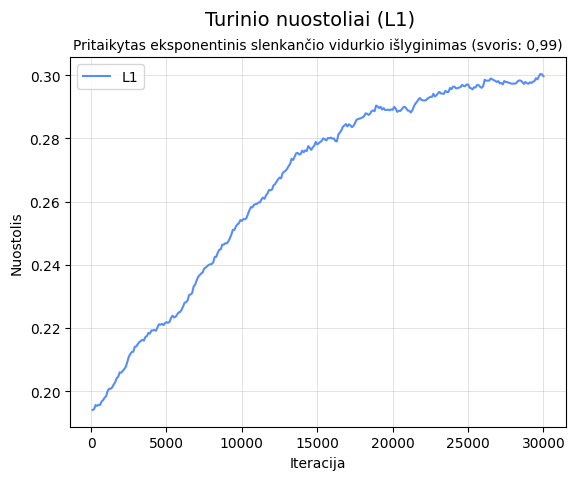

In [78]:
tags_to_plot = ['losses/l_g_pix']

# Plot all tags
for tag in tags_to_plot:
    events = event_acc.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    plt.plot(steps, smooth(values), label='L1')  # Add label for legend

    # Find the smallest value and its step
    min_value = min(values)
    min_step = steps[values.index(min_value)]

# Plot formatting
plt.xlabel("Iteracija")
plt.ylabel("Nuostolis")
plt.suptitle("Turinio nuostoliai (L1)", fontsize=14)
plt.title("Pritaikytas eksponentinis slenkančio vidurkio išlyginimas (svoris: 0,99)", fontsize=10)
plt.legend()
plt.grid(True)
plt.show()

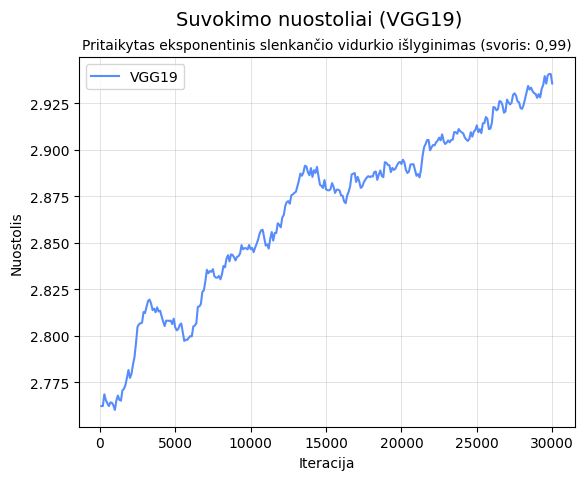

In [79]:
tags_to_plot = ['losses/l_g_percep']

# Plot all tags
for tag in tags_to_plot:
    events = event_acc.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    plt.plot(steps, smooth(values), label='VGG19')  # Add label for legend

    # Find the smallest value and its step
    min_value = min(values)
    min_step = steps[values.index(min_value)]

# Plot formatting
plt.xlabel("Iteracija")
plt.ylabel("Nuostolis")
plt.suptitle("Suvokimo nuostoliai (VGG19)", fontsize=14)
plt.title("Pritaikytas eksponentinis slenkančio vidurkio išlyginimas (svoris: 0,99)", fontsize=10)
plt.legend()
plt.grid(True)
plt.show()

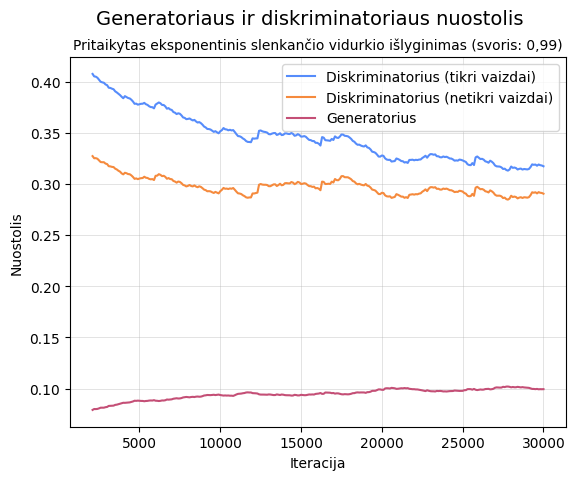

In [80]:
tags_to_plot = ['losses/l_d_real', 'losses/l_d_fake', 'losses/l_g_gan']

label_map = {
    'losses/l_d_real': 'Diskriminatorius (tikri vaizdai)',
    'losses/l_d_fake': 'Diskriminatorius (netikri vaizdai)',
    'losses/l_g_gan' : 'Generatorius'
}

# Plot all tags
for tag in tags_to_plot:
    events = event_acc.Scalars(tag)
    steps = [e.step for e in events[20:]]
    values = [e.value for e in events[20:]]
    plt.plot(steps, smooth(values), label=label_map[tag])  # Add label for legend

    # Find the smallest value and its step
    min_value = min(values)
    min_step = steps[values.index(min_value)]

# Plot formatting
plt.xlabel("Iteracija")
plt.ylabel("Nuostolis")
plt.suptitle("Generatoriaus ir diskriminatoriaus nuostolis", fontsize=14)
plt.title("Pritaikytas eksponentinis slenkančio vidurkio išlyginimas (svoris: 0,99)", fontsize=10)
plt.legend()
plt.grid(True)
plt.show()